In [6]:
import pandas as pd
import networkx as nx
import numpy as np
import community as community_louvain
import leidenalg as la
import igraph as ig
import matplotlib.pyplot as plt

In [7]:
#Preprocessing the data
edges_df = pd.read_csv("enron_weighted_edges.csv")
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Create a directed graph with weighted edges and undirected graph for community detection
G_dir = nx.from_pandas_edgelist(edges_df, 'Source', 'Target', edge_attr='Weight', create_using=nx.DiGraph())
nodes_to_keep = [node for node, degree in G_dir.degree() if degree >= 10]
G = G_dir.subgraph(nodes_to_keep).copy()
G_undir = G.to_undirected()

In [8]:
# Using Louvain and Leiden for community detection
# Louvain
partition_louvain = community_louvain.best_partition(G_undir, weight='Weight')

# Leiden
ig_graph = ig.Graph.TupleList(G_undir.edges(data='Weight'), weights=True)
weights = [float(w) for w in ig_graph.es['weight']]
part_leiden_obj = la.find_partition(ig_graph, la.ModularityVertexPartition, weights=weights)
partition_leiden = {ig_graph.vs[i]['name']: comm_id for i, comm_id in enumerate(part_leiden_obj.membership)}

In [9]:
# Getting community metrics
def get_community_metrics(graph_dir, partition):
    metrics = []
    for comm_id in set(partition.values()):
        nodes = [n for n, c in partition.items() if c == comm_id]
        if len(nodes) < 2: continue

        sub = graph_dir.subgraph(nodes)
        n = len(nodes)
        m = sub.size()

        # Internal Density
        density = m / (n * (n - 1))
        # Average Internal Degree
        avg_int_deg = np.mean([d for n, d in sub.degree()])
        # External Connectivity
        external_edges = sum(1 for n in nodes for nbr in graph_dir.neighbors(n) if nbr not in nodes)
        # Conductance
        total_deg = sum(dict(graph_dir.degree(nodes)).values())
        conductance = external_edges / total_deg if total_deg > 0 else 0

        metrics.append({
            'community_id': comm_id,
            'size': n,
            'internal_density': density,
            'avg_internal_degree': avg_int_deg,
            'external_connectivity': external_edges,
            'conductance': conductance,
            'nodes': nodes
        })
    return pd.DataFrame(metrics)

df_metrics = get_community_metrics(G, partition_leiden)


In [10]:
# Indetify Anomolies by setting high density threshold and low conductance threshold
high_density_thresh = df_metrics['internal_density'].quantile(0.90)
covert_groups = df_metrics[(df_metrics['internal_density'] >= high_density_thresh) &
                           (df_metrics['conductance'] < 0.05)]


In [11]:
# calculating betweenness centrality, use distance as inverse of weight to account for frequency
for u, v, d in G.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

# Calculate betweenness using the new distance attribute
betweenness = nx.betweenness_centrality(G, weight='distance')

top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Bridge Nodes (Corrected for Frequency):")
for node, score in top_bridges:
    print(f"User: {node}, Score: {score:.4f}")

Top 10 Bridge Nodes (Corrected for Frequency):
User: 585, Score: 0.3307
User: 4377, Score: 0.1479
User: 5556, Score: 0.1246
User: 4404, Score: 0.1124
User: 802, Score: 0.0924
User: 3207, Score: 0.0821
User: 18646, Score: 0.0817
User: 4390, Score: 0.0767
User: 743, Score: 0.0726
User: 1070, Score: 0.0715


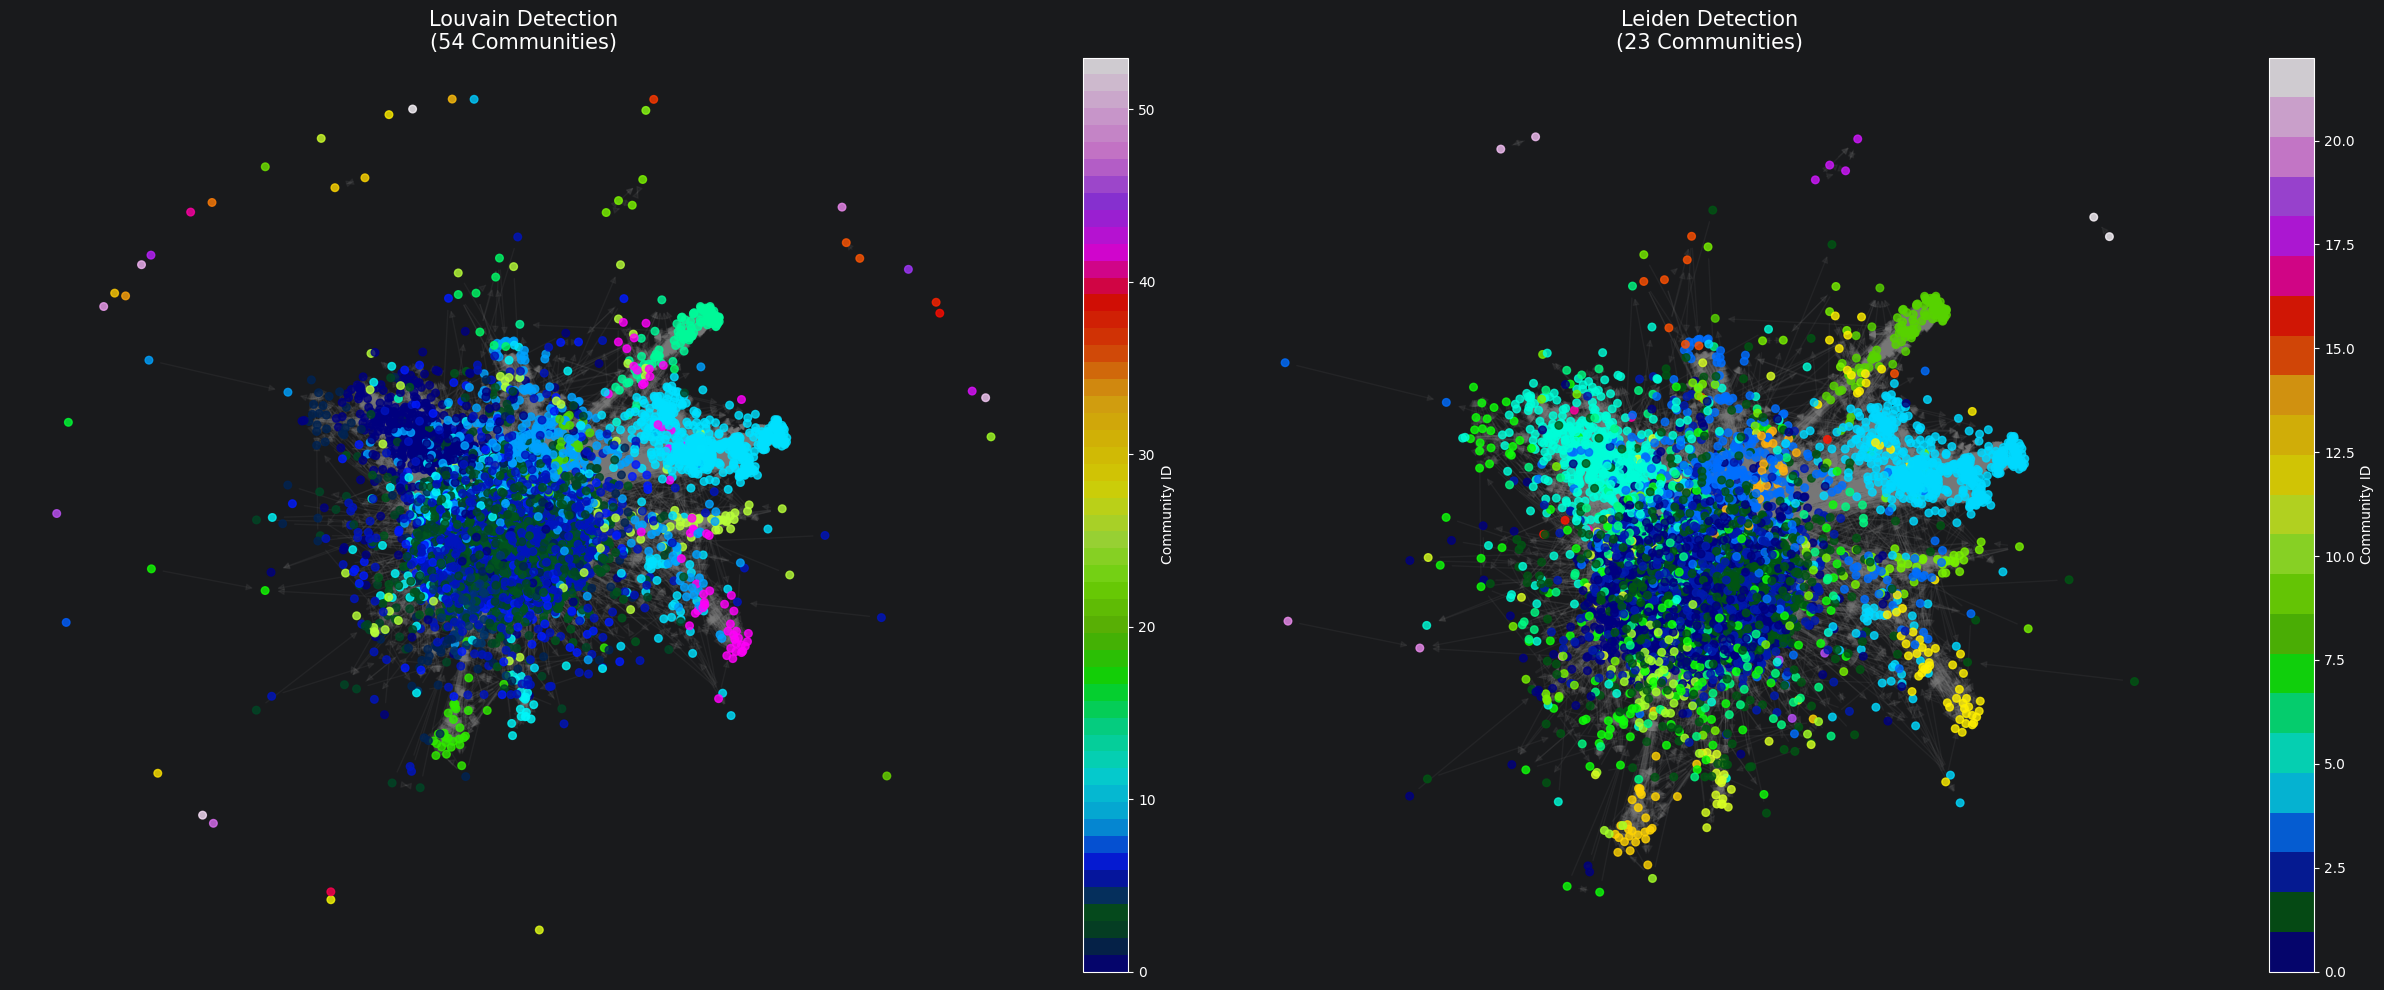

In [13]:
# Create plot for visual comparison
pos = nx.spring_layout(G, k=0.15, seed=42)

# Create figure with two subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Function to draw communities with consistent coloring and layout
def draw_community_plot(ax, partition, title):
    # Assign colors based on community IDs
    unique_comms = len(set(partition.values()))
    cmap = plt.get_cmap('gist_ncar', unique_comms)
    node_colors = [partition.get(node) for node in G.nodes()]

    # Draw nodes and edges
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30,
                                   node_color=node_colors, cmap=cmap, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, edge_color='gray')
    ax.set_title(f"{title}\n({unique_comms} Communities)", fontsize=15)
    ax.axis('off')
    return nodes

# 3. Plot Louvain
nodes_louvain = draw_community_plot(axes[0], partition_louvain, "Louvain Detection")
fig.colorbar(nodes_louvain, ax=axes[0], label="Community ID", fraction=0.046, pad=0.04)

# 4. Plot Leiden
nodes_leiden = draw_community_plot(axes[1], partition_leiden, "Leiden Detection")
fig.colorbar(nodes_leiden, ax=axes[1], label="Community ID", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("enron_community_comparison.png", dpi=300, bbox_inches='tight')
plt.show()